In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

## 1. Imports and Model Loading

In [2]:
import os
import uuid
import imageio
import numpy as np
from IPython.display import Image as ImageDisplay

from inference import Inference, ready_gaussian_for_video_rendering, load_image, load_masks, display_image, make_scene, render_video, interactive_visualizer

/scratch/cl927/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Warp 1.11.0 initialized:
   CUDA Toolkit 12.9, Driver 12.6
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:1"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:2"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:3"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:4"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:5"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:6"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
     "cuda:7"   : "NVIDIA RTX A5000" (24 GiB, sm_86, mempool enabled)
   CUDA peer access:
     Supported fully (all-directional)
   Kernel cache:
     /home/mifs/cl927/.cache/warp/1.11.0


2026-02-20 11:12:43.316 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA RTX A5000


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-02-20 11:12:44.797 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-02-20 11:12:48.651 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-02-20 11:12:49.733 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-02-20 11:12:49.735 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


In [3]:
PATH = os.getcwd()
TAG = "hf"
config_path = f"{PATH}/../checkpoints/{TAG}/pipeline.yaml"
inference = Inference(config_path, compile=False)

2026-02-20 11:12:49.786 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/scratch/cl927/miniconda3/envs/sam3d-objects/lib/python3.11/site-packages/moge/model/v1.py:171: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-02-20 11:13:11.585 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-02-20 11:13:11.587 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.device: cuda
2026-02-20 11:13:11.588 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:101 - CUDA_VISIBLE_DEVICES: None
2026-02-20 11:13:11.588 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:102 - Actually using GPU: 0
2026-02-20 11:13:11.589 | INFO

## 2. Load input image to lift to 3D (multiple objects)

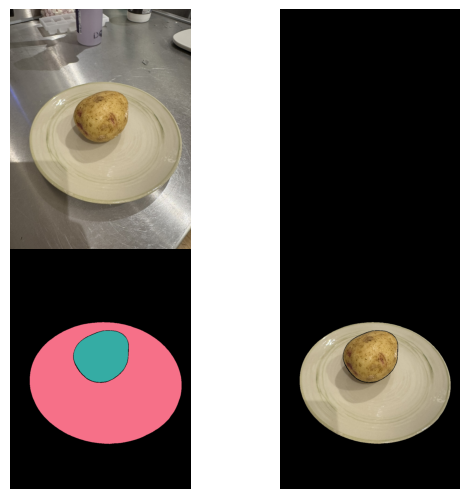

In [4]:
IMAGE_PATH = f"/scratch/cl927/sam-3d-objects/scripts_volume/real_dataset/images/potato_1.jpeg"
IMAGE_NAME = "potato_1"
MASK_PATH = "/scratch/cl927/sam-3d-objects/scripts_volume/real_dataset/masks_potato_1"


image = load_image(IMAGE_PATH)
# masks = load_masks(os.path.dirname(IMAGE_PATH), extension=".png")
masks = load_masks(MASK_PATH, indices_list=[0,1], extension=".png")
display_image(image, masks)

## 3. Generate Gaussian Splats

In [5]:
import torch
torch.cuda.empty_cache()

In [6]:
# outputs = [inference(image, mask, seed=42) for mask in masks]
outputs = []
for mask in masks:
    output = inference(image, mask, seed=42)
    outputs.append(output)

    # Clear cache after each inference to prevent OOM errors
    torch.cuda.empty_cache()

    

2026-02-20 11:21:30.219 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-02-20 11:21:30.220 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-02-20 11:21:30.368 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-02-20 11:21:38.362 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 8848 to 8837
2026-02-20 11:21:38.382 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-02-20 11:21:38.383 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:746 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-02-20 11:21:38.384 | INFO     | sam3d

In [8]:
for output in outputs:
    print(f"Scale: {output['scale']}")

Scale: tensor([[1.0392, 1.0392, 1.0392]], device='cuda:0')
Scale: tensor([[0.4792, 0.4792, 0.4792]], device='cuda:0')


## 4. Visualize Gaussian Splat of the Scene
### a. Animated Gif

In [7]:
scene_gs = make_scene(*outputs)
# export posed gaussian splatting (as point cloud)
scene_gs.save_ply(f"{PATH}/gaussians/{IMAGE_NAME}_posed.ply")

scene_gs = ready_gaussian_for_video_rendering(scene_gs)
# export gaussian splatting (as point cloud)
scene_gs.save_ply(f"{PATH}/gaussians/multi/{IMAGE_NAME}.ply")

video = render_video(
    scene_gs,
    r=1,
    fov=60,
    resolution=512,
)["color"]

# save video as gif
imageio.mimsave(
    os.path.join(f"{PATH}/gaussians/multi/{IMAGE_NAME}.gif"),
    video,
    format="GIF",
    duration=1000 / 30,  # default assuming 30fps from the input MP4
    loop=0,  # 0 means loop indefinitely
)

# notebook display
ImageDisplay(url=f"gaussians/multi/{IMAGE_NAME}.gif?cache_invalidator={uuid.uuid4()}",)

Rendering: 300it [00:02, 146.60it/s]


### b. Interactive Visualizer

In [7]:
# might take a while to load (black screen)
interactive_visualizer(f"{PATH}/gaussians/multi/{IMAGE_NAME}.ply")

PermissionError: [Errno 13] Permission denied: '/tmp/gradio/vibe_edit_history'